## Setup, imports en parameters

In [ ]:
from google.colab import drive
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.utils import Sequence
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Mount Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ==== BELANGRIJKE PARAMETERS =====
SAMPLING_INTERVAL = 5  # Seconden tussen metingen: 5, 15, of 60
DATA_PATH = 'drive/MyDrive/MasterProef/data/home_training.csv'

# Gebruik alleen laatste X% van de data (om 5s snel te kunnen gebruiken zonder out of RAM crash)
GEBRUIK_PERCENTAGE = 100

# Bereken afgeleide parameters
PREDICTION_HOURS = 1  # Altijd 1 uur vooruit voorspellen
PREDICTION_LENGTH = int(PREDICTION_HOURS * 3600 / SAMPLING_INTERVAL)  # Samples voor 1 uur

# Voor SEQUENCE_LENGTH: gebruik een vaste tijdsduur (bijv. 24 minuten historie)
SEQUENCE_MINUTES = 24  # Minuten historie als input
SEQUENCE_LENGTH = int(SEQUENCE_MINUTES * 60 / SAMPLING_INTERVAL)  # Samples voor historie

# Model parameters
LSTM_UNITS = 128
EPOCHS = 100
BATCH_SIZE = 64

print(f"=== Configuratie ===")
print(f"Sampling interval: {SAMPLING_INTERVAL} seconden")
print(f"Sequence length: {SEQUENCE_LENGTH} samples ({SEQUENCE_MINUTES} minuten)")
print(f"Prediction length: {PREDICTION_LENGTH} samples ({PREDICTION_HOURS} uur)")
print(f"Data pad: {DATA_PATH}")
print(f"TensorFlow versie: {tf.__version__}")

=== Configuratie ===
Sampling interval: 5 seconden
Sequence length: 288 samples (24 minuten)
Prediction length: 720 samples (1 uur)
Data pad: drive/MyDrive/MasterProef/data/home_training.csv
TensorFlow versie: 2.18.0


## Feature engineering functies

In [ ]:
def create_time_features(df):
    """Maak tijd-gerelateerde features"""
    # Basis tijd features
    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    df['day'] = df.index.day
    df['month'] = df.index.month

    # Cyclische transformaties
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    df['dayofweek_sin'] = np.sin(2 * np.pi * df['dayofweek'] / 7)
    df['dayofweek_cos'] = np.cos(2 * np.pi * df['dayofweek'] / 7)

    return df

def create_rolling_features(df, sampling_interval):
    """Maak rolling window features"""
    # Window sizes gebaseerd op tijd (5 en 10 minuten)
    window_minutes = [5, 10]
    window_samples = [int(minutes * 60 / sampling_interval) for minutes in window_minutes]

    for i, window in enumerate(window_samples):
        window_min = window_minutes[i]

        # Rolling statistics
        df[f'rolling_mean_{window_min}min'] = df['Power_Value'].rolling(window=window, min_periods=1).mean()
        df[f'rolling_std_{window_min}min'] = df['Power_Value'].rolling(window=window, min_periods=1).std().fillna(0)
        df[f'rolling_min_{window_min}min'] = df['Power_Value'].rolling(window=window, min_periods=1).min()
        df[f'rolling_max_{window_min}min'] = df['Power_Value'].rolling(window=window, min_periods=1).max()

        # Relatieve positie binnen rolling window
        min_vals = df['Power_Value'].rolling(window=window, min_periods=1).min()
        max_vals = df['Power_Value'].rolling(window=window, min_periods=1).max()
        range_vals = max_vals - min_vals
        range_vals = range_vals.replace(0, 1)
        df[f'rolling_position_{window_min}min'] = (df['Power_Value'] - min_vals) / range_vals

    return df

def create_differential_features(df):
    """Maak differentiële features"""
    # Tijd verschillen
    df['time_diff'] = df.index.to_series().diff().dt.total_seconds().fillna(SAMPLING_INTERVAL)
    df['power_diff'] = df['Power_Value'].diff().fillna(0)

    # Rate of change
    df['rate_of_change'] = np.where(df['time_diff'] > 0,
                                   df['power_diff'] / df['time_diff'],
                                   0)

    # Versnelling
    df['acceleration'] = df['rate_of_change'].diff().fillna(0) / df['time_diff'].replace(0, 1)

    # Verwijder tijdelijke kolom
    df = df.drop(columns=['time_diff'])

    return df

def create_solar_features(df):
    """Maak zonne-energie specifieke features"""
    df['is_daytime'] = ((df['hour'] >= 6) & (df['hour'] <= 20)).astype(float)
    df['is_peak_sun'] = ((df['hour'] >= 10) & (df['hour'] <= 16)).astype(float)
    df['hours_since_sunrise'] = np.where(df['hour'] >= 6, df['hour'] - 6, 0)
    df['hours_until_sunset'] = np.where(df['hour'] <= 20, 20 - df['hour'], 0)

    return df

def apply_feature_engineering(df, sampling_interval):
    """Pas alle feature engineering toe"""
    print("\nStart feature engineering...")
    df_features = df.copy()

    # 1. Tijd features
    df_features = create_time_features(df_features)
    print("Tijd features toegevoegd")

    # 2. Rolling window features
    df_features = create_rolling_features(df_features, sampling_interval)
    print("Rolling window features toegevoegd")

    # 3. Differentiële features
    df_features = create_differential_features(df_features)
    print("Differentiële features toegevoegd")

    # 4. Zonne-energie features
    df_features = create_solar_features(df_features)
    print("Zonne-energie features toegevoegd")

    # 5. Verwijder basis tijd kolommen
    cols_to_drop = ['hour', 'dayofweek', 'day', 'month']
    df_features = df_features.drop(columns=cols_to_drop, errors='ignore')

    # 6. Vul NaN waarden op
    numeric_cols = df_features.select_dtypes(include=['float64', 'int64']).columns
    df_features[numeric_cols] = df_features[numeric_cols].fillna(0)

    # Print feature informatie
    print(f"\nTotaal aantal features: {len(df_features.columns)}")
    print(f"Features: {[col for col in df_features.columns if col != 'Power_Value']}")

    return df_features

## Data loading en preprocessing

In [ ]:
def load_and_prepare_data_with_features(file_path, sampling_interval):
    """Laad data en pas feature engineering toe"""
    print(f"Data laden van: {file_path}")
    df = pd.read_csv(file_path)
    # Gebruik alleen laatste deel
    start_idx = int(len(df) * (1 - GEBRUIK_PERCENTAGE/100))
    df = df.iloc[start_idx:]
    print(f"Gebruik {len(df)} samples (laatste {GEBRUIK_PERCENTAGE}%)")
    print(f"Data shape: {df.shape}")

    # Converteer datetime
    df['Datetime'] = pd.to_datetime(df['Datetime'])
    df = df.set_index('Datetime')

    # Check voor missing values
    if df['Power_Value'].isnull().any():
        print(f"Waarschuwing: {df['Power_Value'].isnull().sum()} missing values gevonden")
        df['Power_Value'] = df['Power_Value'].ffill().bfill()

    # Feature engineering
    df_features = apply_feature_engineering(df, sampling_interval)

    # Zorg dat Power_Value de eerste kolom is (voor output extractie)
    cols = df_features.columns.tolist()
    cols.remove('Power_Value')
    cols = ['Power_Value'] + cols
    df_features = df_features[cols]

    # Features voor training
    feature_columns = df_features.columns.tolist()

    # Normaliseer alle features
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(df_features.values)

    print(f"\nData succesvol voorbereid")
    print(f"Aantal features: {scaled_data.shape[1]}")

    return scaled_data, scaler, df_features, feature_columns

def create_sequences_multivariate(data, sequence_length, prediction_length):
    """Maak sequences voor multivariate time series"""
    X, y = [], []

    for i in range(len(data) - sequence_length - prediction_length):
        # Input: alle features
        X.append(data[i:i + sequence_length])
        # Output: alleen Power_Value (eerste kolom)
        y.append(data[i + sequence_length:i + sequence_length + prediction_length, 0])

    X = np.array(X)
    y = np.array(y).reshape(-1, prediction_length, 1)

    return X, y

## LSTM model definitie

In [ ]:
class LSTMPredictorMultivariate(tf.keras.Model):
    def __init__(self, lstm_units, prediction_length, n_features, dropout_rate=0.2):
        super(LSTMPredictorMultivariate, self).__init__()

        self.lstm1 = layers.RNN(
            layers.LSTMCell(lstm_units),
            return_sequences=True,
            return_state=False
        )
        self.dropout1 = layers.Dropout(dropout_rate)

        self.lstm2 = layers.RNN(
            layers.LSTMCell(lstm_units // 2),
            return_sequences=True,
            return_state=False
        )
        self.dropout2 = layers.Dropout(dropout_rate)

        self.lstm3 = layers.RNN(
            layers.LSTMCell(lstm_units // 4),
            return_sequences=False,
            return_state=False
        )
        self.dropout3 = layers.Dropout(dropout_rate)

        self.dense1 = layers.Dense(128, activation='relu')
        self.dropout4 = layers.Dropout(dropout_rate)
        self.dense2 = layers.Dense(prediction_length)

    def call(self, inputs, training=False):
        x = self.lstm1(inputs, training=training)
        x = self.dropout1(x, training=training)

        x = self.lstm2(x, training=training)
        x = self.dropout2(x, training=training)

        x = self.lstm3(x, training=training)
        x = self.dropout3(x, training=training)

        x = self.dense1(x)
        x = self.dropout4(x, training=training)

        output = self.dense2(x)
        return tf.reshape(output, [-1, output.shape[-1], 1])

## Training functies

In [ ]:
def train_model(model, X_train, y_train, X_val, y_val, epochs=50, batch_size=32):
    """Train het model"""
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )

    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    )

    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=0.00001,
        verbose=1
    )

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stopping, reduce_lr],
        verbose=1
    )

    return history

In [ ]:
# ===============
# TRAININGSFUNCTIE MET GENERATOR VOOR GROTE DATASET (5s)
# ===============
class LSTMDataGenerator(Sequence):
    """
    Keras Sequence generator voor LSTM time series data.
    Laadt en verwerkt data on-the-fly om geheugen te besparen.
    """

    def __init__(self, data, sequence_length, prediction_length,
                 batch_size=32, n_features=None, shuffle=True):
        """
        Args:
            data: genormaliseerde numpy array of pandas DataFrame
            sequence_length: aantal historische tijdstappen
            prediction_length: aantal te voorspellen tijdstappen
            batch_size: batch grootte
            n_features: aantal features (indien None, gebruik alle)
            shuffle: shuffle batches na elke epoch
        """
        self.data = data
        self.sequence_length = sequence_length
        self.prediction_length = prediction_length
        self.batch_size = batch_size
        self.n_features = n_features or data.shape[1]
        self.shuffle = shuffle

        # Bereken aantal mogelijke sequences
        self.n_sequences = len(data) - sequence_length - prediction_length
        self.indices = np.arange(self.n_sequences)

        if self.shuffle:
            np.random.shuffle(self.indices)

    def __len__(self):
        """Aantal batches per epoch"""
        return int(np.ceil(self.n_sequences / self.batch_size))

    def __getitem__(self, index):
        """Genereer één batch data"""
        # Bepaal indices voor deze batch
        start_idx = index * self.batch_size
        end_idx = min((index + 1) * self.batch_size, self.n_sequences)
        batch_indices = self.indices[start_idx:end_idx]

        # Initialiseer batch arrays
        X = np.zeros((len(batch_indices), self.sequence_length, self.n_features))
        y = np.zeros((len(batch_indices), self.prediction_length, 1))

        # Vul batch
        for i, idx in enumerate(batch_indices):
            # Input sequence
            X[i] = self.data[idx:idx + self.sequence_length]
            # Output sequence (alleen Power_Value, eerste kolom)
            y[i] = self.data[idx + self.sequence_length:
                           idx + self.sequence_length + self.prediction_length, 0:1]

        return X, y

    def on_epoch_end(self):
        """Wordt aangeroepen aan het einde van elke epoch"""
        if self.shuffle:
            np.random.shuffle(self.indices)

def train_model_with_generator(model, train_generator, val_generator,
                              epochs=50, callbacks=None):
    """Train model met data generators"""

    if callbacks is None:
        callbacks = [
            tf.keras.callbacks.EarlyStopping(
                monitor='val_loss',
                patience=10,
                restore_best_weights=True,
                verbose=1
            ),
            tf.keras.callbacks.ReduceLROnPlateau(
                monitor='val_loss',
                factor=0.5,
                patience=5,
                min_lr=0.00001,
                verbose=1
            )
        ]

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )

    history = model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=epochs,
        callbacks=callbacks,
        verbose=1
    )

    return history

## Hoofdprogramma

In [ ]:
print("\n=== LSTM Time Series Voorspelling Start ===")
# 1. Data laden met features
scaled_data, scaler, df_features, feature_columns = load_and_prepare_data_with_features(
    DATA_PATH, SAMPLING_INTERVAL
)
n_features = scaled_data.shape[1]


=== LSTM Time Series Voorspelling Start ===
Data laden van: drive/MyDrive/MasterProef/data/home_training.csv
Gebruik 267743 samples (laatste 100%)
Data shape: (267743, 2)

Start feature engineering...
Tijd features toegevoegd
Rolling window features toegevoegd
Differentiële features toegevoegd
Zonne-energie features toegevoegd

Totaal aantal features: 22
Features: ['hour_sin', 'hour_cos', 'dayofweek_sin', 'dayofweek_cos', 'rolling_mean_5min', 'rolling_std_5min', 'rolling_min_5min', 'rolling_max_5min', 'rolling_position_5min', 'rolling_mean_10min', 'rolling_std_10min', 'rolling_min_10min', 'rolling_max_10min', 'rolling_position_10min', 'power_diff', 'rate_of_change', 'acceleration', 'is_daytime', 'is_peak_sun', 'hours_since_sunrise', 'hours_until_sunset']

Data succesvol voorbereid
Aantal features: 22



=== LSTM Time Series Voorspelling Start ===
Data laden van: drive/MyDrive/MasterProef/data/home_training.csv
Gebruik 267743 samples (laatste 100%)
Data shape: (267743, 2)

Start feature engineering...
Tijd features toegevoegd
Rolling window features toegevoegd
Differentiële features toegevoegd
Zonne-energie features toegevoegd

Totaal aantal features: 22
Features: ['hour_sin', 'hour_cos', 'dayofweek_sin', 'dayofweek_cos', 'rolling_mean_5min', 'rolling_std_5min', 'rolling_min_5min', 'rolling_max_5min', 'rolling_position_5min', 'rolling_mean_10min', 'rolling_std_10min', 'rolling_min_10min', 'rolling_max_10min', 'rolling_position_10min', 'power_diff', 'rate_of_change', 'acceleration', 'is_daytime', 'is_peak_sun', 'hours_since_sunrise', 'hours_until_sunset']

Data succesvol voorbereid
Aantal features: 22

Dagpatroon analyse...


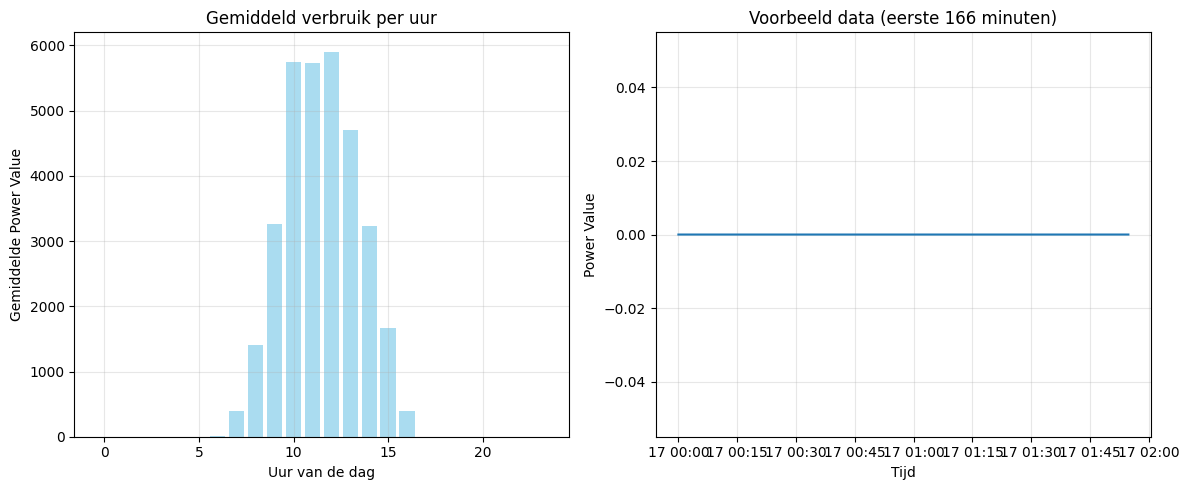


Sequences maken...


In [ ]:
# ================================
# ========== BLOK ZONDER GENERATOR
# ================================

# Visualiseer dagpatronen
print("\nDagpatroon analyse...")
df_features['hour'] = df_features.index.hour
hourly_avg = df_features.groupby('hour')['Power_Value'].agg(['mean', 'std', 'max'])

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.bar(hourly_avg.index, hourly_avg['mean'], alpha=0.7, color='skyblue')
plt.xlabel('Uur van de dag')
plt.ylabel('Gemiddelde Power Value')
plt.title('Gemiddeld verbruik per uur')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(df_features.index[:2000], df_features['Power_Value'][:2000])
plt.title(f'Voorbeeld data (eerste {2000 * SAMPLING_INTERVAL // 60} minuten)')
plt.xlabel('Tijd')
plt.ylabel('Power Value')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 2. Sequences maken
print(f"\nSequences maken...")
X, y = create_sequences_multivariate(scaled_data, SEQUENCE_LENGTH, PREDICTION_LENGTH)
print(f"Input shape: {X.shape} (samples, tijdstappen, features)")
print(f"Output shape: {y.shape} (samples, voorspellingen, 1)")

# 3. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=False
)
print(f"Training samples: {len(X_train)}, Test samples: {len(X_test)}")

# 4. Model bouwen
print("\nModel bouwen...")
model = LSTMPredictorMultivariate(
    lstm_units=LSTM_UNITS,
    prediction_length=PREDICTION_LENGTH,
    n_features=n_features,
    dropout_rate=0.2
)

model.build(input_shape=(None, SEQUENCE_LENGTH, n_features))
model.summary()

# 5. Model trainen
print("\nModel trainen...")
history = train_model(
    model, X_train, y_train, X_test, y_test,
    epochs=EPOCHS, batch_size=BATCH_SIZE
)

# 6. Evaluatie
print("\n=== Model Evaluatie ===")
test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss (MSE): {test_loss:.6f}")
print(f"Test MAE: {test_mae:.6f}")

# Denormaliseer MAE
denorm_mae = test_mae * (df_features['Power_Value'].max() - df_features['Power_Value'].min())
print(f"Test MAE (denormalized): {denorm_mae:.4f}")

print("\n=== Training Compleet! ===")
print(f"Model getraind voor {SAMPLING_INTERVAL}s sampling interval")
print(f"Voorspelt {PREDICTION_LENGTH} samples ({PREDICTION_HOURS} uur) vooruit")
print(f"Gebruikt {SEQUENCE_LENGTH} samples ({SEQUENCE_MINUTES} minuten) historie")
print(f"Met {n_features} features")

In [ ]:
# ================================
# ========== BLOK MET GENERATOR INCLUSIEF EVALUATIE
# ================================

# 1. Splits data eerst
train_size = int(0.8 * len(scaled_data))
train_data = scaled_data[:train_size]
test_data = scaled_data[train_size:]

print(f"Train size: {train_size}, Test size: {len(test_data)}")

# 2. Maak generators
BATCH_SIZE = 196  # Verlaag indien nodig

train_generator = LSTMDataGenerator(
    train_data,
    sequence_length=SEQUENCE_LENGTH,
    prediction_length=PREDICTION_LENGTH,
    batch_size=BATCH_SIZE,
    n_features=n_features,
    shuffle=True
)

val_generator = LSTMDataGenerator(
    test_data,
    sequence_length=SEQUENCE_LENGTH,
    prediction_length=PREDICTION_LENGTH,
    batch_size=BATCH_SIZE,
    n_features=n_features,
    shuffle=False
)

print(f"Train batches: {len(train_generator)}, Val batches: {len(val_generator)}")

# 3. Model bouwen
print("\nModel bouwen...")
model = LSTMPredictorMultivariate(
    lstm_units=LSTM_UNITS,
    prediction_length=PREDICTION_LENGTH,
    n_features=n_features,
    dropout_rate=0.2
)

model.build(input_shape=(None, SEQUENCE_LENGTH, n_features))
model.summary()

# 4. Train model
history = train_model_with_generator(
    model, train_generator, val_generator,
    epochs=EPOCHS
)



Train size: 214194, Test size: 53549
Train batches: 1088, Val batches: 269

Model bouwen...


Model: "lstm_predictor_multivariate_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rnn_6 (RNN)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn_7 (RNN)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn_8 (RNN)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 136s 115ms/step - loss: 0.0082 - mae: 0.0418 - val_loss: 0.0160 - val_mae: 0.0477 - learning_rate: 0.0010
Epoch 2/100
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 118s 108ms/step - loss: 0.0027 - mae: 0.0271 - val_loss: 0.0171 - val_mae: 0.0511 - learning_rate: 0.0010
Epoch 3/100
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 118s 108ms/step - loss: 0.0025 - mae: 0.0257 - val_loss: 0.0177 - val_mae: 0.0520 - learning_rate: 0.0010
Epoch 4/100
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 142s 108ms/step - loss: 0.0022 - mae: 0.0238 - val_loss: 0.0168 - val_mae: 0.0525 - learning_rate: 0.0010
Epoch 5/100
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 118s 108ms/step - loss: 0.0020 - mae: 0.0226 - val_loss: 0.0178 - val_mae: 0.0533 - learning_rate: 0.0010
Epoch 6/100
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - loss: 0.0019 - mae: 0.0219
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 118s 108ms/step - loss: 0.0019 - mae: 0.0219 - val_loss: 0.018

In [ ]:
# ============ MEMORY-EFFICIENT EVALUATIE ============
def evaluate_with_generator(model, data, scaler, sequence_length,
                          prediction_length, n_features, num_samples=100):
    """Evalueer model zonder alle data in geheugen te laden"""

    mse_scores = []
    mae_scores = []

    # Bepaal indices om te evalueren
    n_possible = len(data) - sequence_length - prediction_length
    sample_indices = np.random.choice(n_possible, size=min(num_samples, n_possible),
                                    replace=False)

    for idx in sample_indices:
        # Haal één sequence op
        X = data[idx:idx + sequence_length].reshape(1, sequence_length, n_features)
        y_true = data[idx + sequence_length:
                     idx + sequence_length + prediction_length, 0]

        # Voorspel
        y_pred = model.predict(X, verbose=0)[0, :, 0]

        # Denormaliseer
        dummy_true = np.zeros((len(y_true), n_features))
        dummy_true[:, 0] = y_true
        true_denorm = scaler.inverse_transform(dummy_true)[:, 0]

        dummy_pred = np.zeros((len(y_pred), n_features))
        dummy_pred[:, 0] = y_pred
        pred_denorm = scaler.inverse_transform(dummy_pred)[:, 0]

        # Bereken metrics
        mse = mean_squared_error(true_denorm, pred_denorm)
        mae = mean_absolute_error(true_denorm, pred_denorm)

        mse_scores.append(mse)
        mae_scores.append(mae)

    print(f"\nEvaluatie op {len(mse_scores)} samples:")
    print(f"Gemiddelde MSE: {np.mean(mse_scores):.2f}")
    print(f"Gemiddelde MAE: {np.mean(mae_scores):.2f}")
    print(f"Gemiddelde RMSE: {np.sqrt(np.mean(mse_scores)):.2f}")

# Gebruik voor evaluatie:
evaluate_with_generator(
    model, test_data, scaler,
    SEQUENCE_LENGTH, PREDICTION_LENGTH, n_features,
    num_samples=200
)


Evaluatie op 200 samples:
Gemiddelde MSE: 1833814.25
Gemiddelde MAE: 499.79
Gemiddelde RMSE: 1354.18


## Voorspellingen en visualisatie

In [ ]:
def make_predictions_multivariate(model, X_sample, scaler, n_features):
    """Maak voorspellingen en denormaliseer"""
    prediction_scaled = model.predict(X_sample, verbose=0)

    # Maak dummy array voor denormalisatie
    dummy_array = np.zeros((prediction_scaled.shape[1], n_features))
    dummy_array[:, 0] = prediction_scaled[0, :, 0]

    prediction_denorm = scaler.inverse_transform(dummy_array)
    return prediction_denorm[:, 0]

# Selecteer interessante voorbeelden
print("\nSelecteer interessante voorbeelden...")
test_start_idx = len(X_train) + SEQUENCE_LENGTH
test_timestamps = df_features.index[test_start_idx:test_start_idx + len(X_test)]

# Vind overdag samples met activiteit
interesting_indices = []
for i in range(min(100, len(X_test))):
    timestamp = test_timestamps[i]
    hour = timestamp.hour

    # Denormaliseer om werkelijke waarden te checken
    actual_values = make_predictions_multivariate(
        model, X_test[i:i+1], scaler, n_features
    )
    avg_power = np.mean(actual_values)

    if 8 <= hour <= 18 and avg_power > 5:
        interesting_indices.append(i)
        if len(interesting_indices) >= 4:
            break

# Als niet genoeg overdag samples, neem willekeurige
if len(interesting_indices) < 2:
    interesting_indices = list(range(0, min(4, len(X_test))))

# Maak voorspellingen en plot
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for idx, test_idx in enumerate(interesting_indices[:4]):
    # Voorspelling
    pred = make_predictions_multivariate(model, X_test[test_idx:test_idx+1], scaler, n_features)

    # Werkelijke waarden
    actual_scaled = y_test[test_idx, :, 0]
    dummy_actual = np.zeros((len(actual_scaled), n_features))
    dummy_actual[:, 0] = actual_scaled
    actual = scaler.inverse_transform(dummy_actual)[:, 0]

    # Plot
    time_steps = np.arange(PREDICTION_LENGTH) * SAMPLING_INTERVAL / 60
    axes[idx].plot(time_steps, actual, label='Werkelijk', alpha=0.7, linewidth=2)
    axes[idx].plot(time_steps, pred, label='Voorspelling', alpha=0.7, linewidth=2)
    axes[idx].set_xlabel('Tijd (minuten)')
    axes[idx].set_ylabel('Power Value')
    axes[idx].set_title(f'Voorspelling vanaf {test_timestamps[test_idx].strftime("%d-%m %H:%M")}')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Plot training geschiedenis
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Model MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Selecteer interessante voorbeelden...


NameError: name 'X_train' is not defined

## Model Evaluatie met MSE, MAE en R²

In [ ]:
def evaluate_multistep_model(model, X_test, y_test, scaler, n_features, num_samples=100):
    """
    Evalueert het multi-step model op de testset.

    Args:
        model: getraind LSTM model
        X_test: test input data
        y_test: test output data
        scaler: fitted scaler voor denormalisatie
        n_features: aantal features in het model
        num_samples: aantal samples om te evalueren
    """
    mse_scores = []
    mae_scores = []
    r2_scores = []
    true_values_all = []
    predicted_values_all = []

    # Beperk tot num_samples of het beschikbare aantal
    num_samples = min(num_samples, len(X_test))

    print(f"Evalueer {num_samples} voorspellingen...")

    for i in range(num_samples):
        # Voorspel voor één sample
        input_seq = X_test[i:i+1]
        predictions = model.predict(input_seq, verbose=0)

        # Haal werkelijke waarden op
        true_values = y_test[i, :, 0]  # Alleen Power_Value (eerste kolom)
        predictions = predictions[0, :, 0]  # Flatten predictions

        # Schaal terug naar originele waarden
        # Maak dummy arrays met juiste aantal features
        dummy_pred = np.zeros((len(predictions), n_features))
        dummy_pred[:, 0] = predictions  # Power_Value is eerste kolom
        predictions_orig = scaler.inverse_transform(dummy_pred)[:, 0]

        dummy_true = np.zeros((len(true_values), n_features))
        dummy_true[:, 0] = true_values
        true_values_orig = scaler.inverse_transform(dummy_true)[:, 0]

        # Bereken metrics
        mse = mean_squared_error(true_values_orig, predictions_orig)
        mae = mean_absolute_error(true_values_orig, predictions_orig)

        # R² kan negatief zijn voor slechte voorspellingen
        try:
            r2 = r2_score(true_values_orig, predictions_orig)
        except:
            r2 = np.nan

        mse_scores.append(mse)
        mae_scores.append(mae)
        if not np.isnan(r2):
            r2_scores.append(r2)
        true_values_all.append(true_values_orig)
        predicted_values_all.append(predictions_orig)

    # Print gemiddelde metrics
    print(f"\n=== Multi-step Model Evaluatie Resultaten ===")
    print(f"Geëvalueerd op {num_samples} samples")
    print(f"Gemiddelde MSE: {np.mean(mse_scores):.4f} (std: {np.std(mse_scores):.4f})")
    print(f"Gemiddelde MAE: {np.mean(mae_scores):.4f} (std: {np.std(mae_scores):.4f})")
    print(f"Gemiddelde RMSE: {np.sqrt(np.mean(mse_scores)):.4f}")
    if r2_scores:
        print(f"Gemiddelde R²: {np.mean(r2_scores):.4f} (std: {np.std(r2_scores):.4f})")
    else:
        print("R² kon niet berekend worden")

    # Bereken ook overall metrics (alle voorspellingen samen)
    all_true = np.concatenate(true_values_all)
    all_pred = np.concatenate(predicted_values_all)
    overall_mse = mean_squared_error(all_true, all_pred)
    overall_mae = mean_absolute_error(all_true, all_pred)
    overall_r2 = r2_score(all_true, all_pred)

    print(f"\n=== Overall Metrics (alle voorspellingen samen) ===")
    print(f"Overall MSE: {overall_mse:.4f}")
    print(f"Overall MAE: {overall_mae:.4f}")
    print(f"Overall RMSE: {np.sqrt(overall_mse):.4f}")
    print(f"Overall R²: {overall_r2:.4f}")

    return true_values_all, predicted_values_all, {
        'mse_scores': mse_scores,
        'mae_scores': mae_scores,
        'r2_scores': r2_scores,
        'overall_mse': overall_mse,
        'overall_mae': overall_mae,
        'overall_r2': overall_r2
    }

def visualize_multistep_predictions(true_values, predicted_values, sampling_interval, idx=None):
    """
    Visualiseert de multi-step voorspellingen.

    Args:
        true_values: lijst met werkelijke waarden
        predicted_values: lijst met voorspelde waarden
        sampling_interval: tijd tussen samples in seconden
        idx: index van de voorspelling om te visualiseren
    """
    if len(true_values) == 0:
        print("Geen voorspellingen beschikbaar om te visualiseren.")
        return

    if idx is None:
        idx = np.random.randint(0, len(true_values))
    else:
        idx = min(idx, len(true_values)-1)

    # Bereken metrics voor dit specifieke voorbeeld
    mse = mean_squared_error(true_values[idx], predicted_values[idx])
    mae = mean_absolute_error(true_values[idx], predicted_values[idx])
    r2 = r2_score(true_values[idx], predicted_values[idx])

    # Tijdlabels in minuten
    minute_labels = np.arange(len(true_values[idx])) * sampling_interval / 60

    # Maak subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))

    # Plot 1: Voorspelling vs werkelijkheid
    ax1.plot(minute_labels, true_values[idx], 'b-', label='Werkelijke waarden', linewidth=2)
    ax1.plot(minute_labels, predicted_values[idx], 'r--', label='Voorspellingen', linewidth=2)
    ax1.set_title(f'1-uur Voorspelling vs. Werkelijke Waarden\nMSE: {mse:.2f}, MAE: {mae:.2f}, R²: {r2:.4f}',
                  fontsize=14)
    ax1.set_xlabel('Tijd (minuten)')
    ax1.set_ylabel('Power Value')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Voeg statistieken toe
    ax1.text(0.02, 0.98, f'Max werkelijk: {np.max(true_values[idx]):.2f}\n'
                         f'Max voorspeld: {np.max(predicted_values[idx]):.2f}\n'
                         f'Gem. werkelijk: {np.mean(true_values[idx]):.2f}\n'
                         f'Gem. voorspeld: {np.mean(predicted_values[idx]):.2f}',
             transform=ax1.transAxes, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    # Plot 2: Absolute fout
    error = np.abs(true_values[idx] - predicted_values[idx])
    ax2.plot(minute_labels, error, 'g-', label='Absolute fout', linewidth=2)
    ax2.axhline(y=mae, color='r', linestyle='--', label=f'Gemiddelde fout (MAE): {mae:.2f}')
    ax2.fill_between(minute_labels, 0, error, alpha=0.3, color='green')
    ax2.set_title('Absolute Voorspellingsfout')
    ax2.set_xlabel('Tijd (minuten)')
    ax2.set_ylabel('Absolute fout')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def plot_error_distribution(metrics):
    """Plot de verdeling van errors"""
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # MSE distributie
    axes[0].hist(metrics['mse_scores'], bins=30, alpha=0.7, color='blue', edgecolor='black')
    axes[0].axvline(np.mean(metrics['mse_scores']), color='red', linestyle='--',
                    label=f'Gem: {np.mean(metrics["mse_scores"]):.2f}')
    axes[0].set_xlabel('MSE')
    axes[0].set_ylabel('Frequentie')
    axes[0].set_title('MSE Distributie')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # MAE distributie
    axes[1].hist(metrics['mae_scores'], bins=30, alpha=0.7, color='green', edgecolor='black')
    axes[1].axvline(np.mean(metrics['mae_scores']), color='red', linestyle='--',
                    label=f'Gem: {np.mean(metrics["mae_scores"]):.2f}')
    axes[1].set_xlabel('MAE')
    axes[1].set_ylabel('Frequentie')
    axes[1].set_title('MAE Distributie')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # R² distributie
    if metrics['r2_scores']:
        axes[2].hist(metrics['r2_scores'], bins=30, alpha=0.7, color='orange', edgecolor='black')
        axes[2].axvline(np.mean(metrics['r2_scores']), color='red', linestyle='--',
                        label=f'Gem: {np.mean(metrics["r2_scores"]):.4f}')
        axes[2].set_xlabel('R²')
        axes[2].set_ylabel('Frequentie')
        axes[2].set_title('R² Score Distributie')
        axes[2].legend()
        axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# ============ HOOFDCODE VOOR EVALUATIE ============
# Voer de evaluatie uit
print("\n" + "="*50)
print("START MODEL EVALUATIE")
print("="*50)

# Evalueer het model
true_values, pred_values, metrics = evaluate_multistep_model(
    model, X_test, y_test, scaler, n_features,
    num_samples=min(200, len(X_test))  # Evalueer max 200 samples
)

# Plot error distributie
print("\nError distributie visualisatie:")
plot_error_distribution(metrics)

# Visualiseer enkele voorbeelden
if len(true_values) > 0:
    # Toon een willekeurige voorspelling
    print("\nVisualisatie van een willekeurige voorspelling:")
    visualize_multistep_predictions(true_values, pred_values, SAMPLING_INTERVAL)

    # Vind beste en slechtste voorspellingen
    if len(true_values) > 1:
        mse_per_prediction = [mean_squared_error(true_values[i], pred_values[i])
                             for i in range(len(true_values))]
        best_idx = np.argmin(mse_per_prediction)
        worst_idx = np.argmax(mse_per_prediction)

        print(f"\nBeste voorspelling (laagste MSE = {mse_per_prediction[best_idx]:.2f}):")
        visualize_multistep_predictions(true_values, pred_values, SAMPLING_INTERVAL, best_idx)

        print(f"\nSlechtste voorspelling (hoogste MSE = {mse_per_prediction[worst_idx]:.2f}):")
        visualize_multistep_predictions(true_values, pred_values, SAMPLING_INTERVAL, worst_idx)

# ============ Extra: Tijdsafhankelijke Error Analyse ============
def analyze_temporal_errors(true_values, pred_values, sampling_interval):
    """Analyseer hoe de error zich ontwikkelt over de voorspellingsperiode"""

    # Bereken gemiddelde error per tijdstap
    n_steps = len(true_values[0])
    mae_per_step = []

    for step in range(n_steps):
        errors_at_step = [np.abs(true_values[i][step] - pred_values[i][step])
                         for i in range(len(true_values))]
        mae_per_step.append(np.mean(errors_at_step))

    # Plot
    plt.figure(figsize=(12, 6))
    minutes = np.arange(n_steps) * sampling_interval / 60
    plt.plot(minutes, mae_per_step, 'b-', linewidth=2)
    plt.fill_between(minutes, 0, mae_per_step, alpha=0.3)
    plt.xlabel('Voorspellingstijd (minuten)')
    plt.ylabel('Gemiddelde Absolute Error')
    plt.title('Error Ontwikkeling over Voorspellingsperiode')
    plt.grid(True, alpha=0.3)

    # Voeg trend lijn toe
    z = np.polyfit(minutes, mae_per_step, 1)
    p = np.poly1d(z)
    plt.plot(minutes, p(minutes), "r--", alpha=0.8,
             label=f'Trend: {z[0]:.4f}x + {z[1]:.4f}')
    plt.legend()
    plt.show()

    print(f"\nTemporele error analyse:")
    print(f"Error bij start: {mae_per_step[0]:.4f}")
    print(f"Error bij einde: {mae_per_step[-1]:.4f}")
    print(f"Error toename: {mae_per_step[-1] - mae_per_step[0]:.4f}")
    print(f"Relatieve toename: {(mae_per_step[-1] - mae_per_step[0]) / mae_per_step[0] * 100:.1f}%")

# Voer temporele analyse uit
print("\n" + "="*50)
print("TEMPORELE ERROR ANALYSE")
print("="*50)
analyze_temporal_errors(true_values, pred_values, SAMPLING_INTERVAL)


START MODEL EVALUATIE


NameError: name 'X_test' is not defined

## Model opslaan

In [ ]:
print("\nModel en configuratie opslaan...")

# Sla model op
model_save_path = f'/content/drive/MyDrive/MasterProef/definitive/models/lstm_multivariate_{SAMPLING_INTERVAL}s.keras'
model.save(model_save_path)
print(f"Model opgeslagen: {model_save_path}")

# Sla scaler op
import joblib
scaler_path = f'/content/drive/MyDrive/MasterProef/definitive/scalers/scaler_multivariate_{SAMPLING_INTERVAL}s.pkl'
joblib.dump(scaler, scaler_path)
print(f"Scaler opgeslagen: {scaler_path}")

# Sla configuratie op
config = {
    'sampling_interval': SAMPLING_INTERVAL,
    'sequence_length': SEQUENCE_LENGTH,
    'prediction_length': PREDICTION_LENGTH,
    'n_features': n_features,
    'feature_columns': feature_columns,
    'lstm_units': LSTM_UNITS
}

import json
config_path = f'/content/drive/MyDrive/MasterProef/config_{SAMPLING_INTERVAL}s.json'
with open(config_path, 'w') as f:
    json.dump(config, f, indent=2)
print(f"Configuratie opgeslagen: {config_path}")


Model en configuratie opslaan...
Model opgeslagen: /content/drive/MyDrive/MasterProef/definitive/models/lstm_multivariate_60s.keras
Scaler opgeslagen: /content/drive/MyDrive/MasterProef/definitive/scalers/scaler_multivariate_60s.pkl
Configuratie opgeslagen: /content/drive/MyDrive/MasterProef/config_60s.json


## Voorspelling functies


Data range: 2025-04-01 00:00:45 tot 2025-04-15 23:59:45
Voorspelling wordt gemaakt voor: 2025-04-10 11:00:00
Exact tijdstip niet gevonden, gebruik 2025-04-10 10:59:45


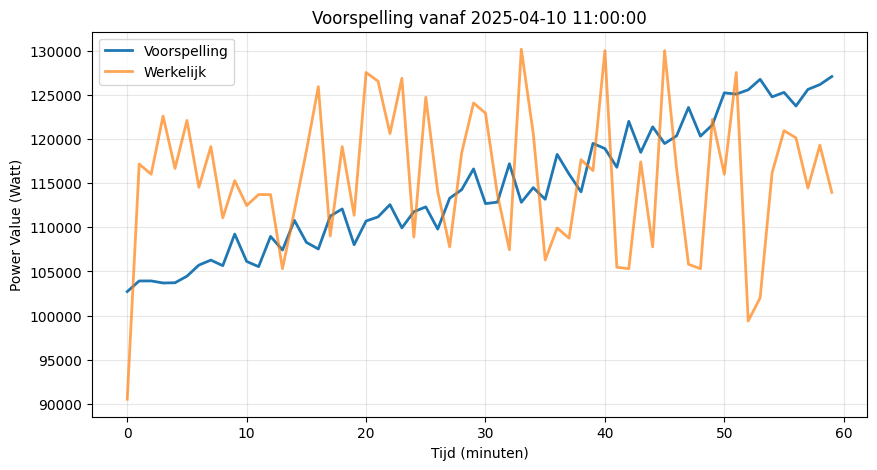

In [ ]:
def predict_at_specific_time_multivariate(df_features, model, scaler, target_datetime,
                                         sequence_length, feature_columns, n_features):
    """Voorspel vanaf specifiek tijdstip met alle features"""
    if isinstance(target_datetime, str):
        target_datetime = pd.to_datetime(target_datetime)

    try:
        target_idx = df_features.index.get_loc(target_datetime)
    except:
        target_idx = df_features.index.get_indexer([target_datetime], method='nearest')[0]
        print(f"Exact tijdstip niet gevonden, gebruik {df_features.index[target_idx]}")

    if target_idx < sequence_length:
        print("Niet genoeg historische data")
        return None, None

    # Haal input data op
    input_data = df_features[feature_columns].iloc[target_idx-sequence_length:target_idx].values
    input_scaled = scaler.transform(input_data)
    input_sequence = input_scaled.reshape(1, sequence_length, n_features)

    # Voorspel
    prediction = make_predictions_multivariate(model, input_sequence, scaler, n_features)

    # Werkelijke waarden indien beschikbaar
    actual = None
    if target_idx + PREDICTION_LENGTH <= len(df_features):
        actual = df_features['Power_Value'].iloc[target_idx:target_idx+PREDICTION_LENGTH].values

    return prediction, actual

# Test voorspelling op specifiek tijdstip
print(f"\nData range: {df_features.index.min()} tot {df_features.index.max()}")
example_time = "2025-04-10 11:00:00"  # Format: "YYYY-MM-DD HH:MM:SS"

if isinstance(example_time, str):
    example_time = pd.to_datetime(example_time)

print(f"Voorspelling wordt gemaakt voor: {example_time}")

try:
    pred, actual = predict_at_specific_time_multivariate(
        df_features, model, scaler, example_time,
        SEQUENCE_LENGTH, feature_columns, n_features
    )

    if pred is not None:
        plt.figure(figsize=(10, 5))
        time_steps = np.arange(len(pred)) * SAMPLING_INTERVAL / 60
        plt.plot(time_steps, pred, label='Voorspelling', linewidth=2)
        if actual is not None:
            plt.plot(time_steps, actual, label='Werkelijk', alpha=0.7, linewidth=2)
        plt.xlabel('Tijd (minuten)')
        plt.ylabel('Power Value (Watt)')
        plt.title(f'Voorspelling vanaf {example_time}')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()
except Exception as e:
    print(f"Voorspelling mislukt: {e}")